In [1]:
# Inverse modelling of magnetic anomaly over a mid-ocean ridge
# Using L1 norm, total variation, robust estimation and IRLS

# For DTU MSc course Inverse Problems in Earth and Space Physics

# Starting script setting up problem, and synthetic data

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def G_crust(x_j, x_m, h):
    # Regarding constant pre-factor [not crucial for understanding]
    # -\mu_0/2pi = -2 x10-^7
    # But Magnetization in SI Am^-1, data in nT=10^-9 T
    # So finally correct prefactor is -200 [See Parker, 1994 for details] 
    
    x_m = x_m.reshape(1,-1)
    x_j = x_j.reshape(-1,1)
    g= -200 * ((x_m - x_j)**2 - h**2) /((x_m - x_j)**2 + h**2 )**2

    return g


In [3]:
# Set up 1D grid for locations of model magnetization
delta_x_m=0.1
x_m=np.arange(-25, 25+delta_x_m, delta_x_m)

# define data locations
x_j=np.arange(-15,15+1,1)

# Build design matrix
h=2 # Depth of water (km)
G = G_crust(x_j, x_m, h)*delta_x_m

In [4]:
# Define synthetic model
m = np.zeros((len(x_m),1))
ones = np.ones((51,1))

m[np.arange(250-127,251-77)] = 2*ones
m[np.arange(250-76,251-26)] = -2*ones
m[np.arange(250-25,251+25)] = 2*ones
m[np.arange(250+26,251+76)] = -2*ones
m[np.arange(250+77,251+127)] = 2*ones

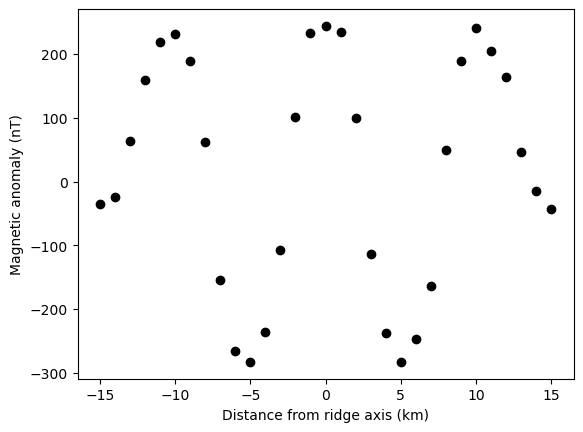

In [5]:
# Produce synthetic data
d_j=G@m

#dn_j=8*np.random.rand(len(d_j),1) Old version, error in noise.
dn_j=8*np.random.normal(0,1,d_j.shape)
d_j=d_j+dn_j

# Plot data
plt.figure()
plt.plot(x_j,d_j, 'ko')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel('Magnetic anomaly (nT)')
plt.show()

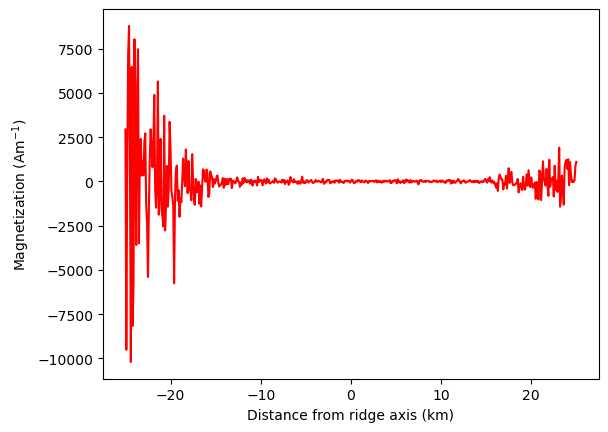

rms misfit: 2.164078587850565e-12


In [6]:
# Simple least squares soln.
m_ls = np.linalg.solve((G.T@G),G.T@d_j) # Direct least sq inversion: v. poor result

# Plot simple least squares soln
plt.figure()
plt.plot(x_m,m_ls,'-r')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

# Residuals
r_ls=d_j-G@m_ls;
# rms misfit
rms_resid_ls=np.sqrt(r_ls.T@r_ls/len(d_j))
print("rms misfit:", rms_resid_ls[0,0])

In [7]:
residual_list = []
alpha_sq_list = np.logspace(2, 1, 50)

# L2 norm Tikhonov Regularized solution
for alpha_sq in alpha_sq_list:
    GTG=G.T@G

    # Determine Tikhonov solution
    I = np.identity(len(GTG))
    m_L2tik = np.linalg.solve((GTG + alpha_sq*I), G.T@d_j)

    # Residuals
    r_L2tik=d_j-G@m_L2tik
    # rms misfit
    rms_resid_L2tik=np.sqrt(r_L2tik.T@r_L2tik/len(d_j))
    residual_list.append(rms_resid_L2tik)

residual_list = np.squeeze(residual_list)

In [8]:
discrepancy_index = np.where(residual_list > 8)[0][-1]
print('residual=', residual_list[discrepancy_index], 'and corresponding alpha squared=', alpha_sq_list[discrepancy_index])

residual= 8.12773966672514 and corresponding alpha squared= 33.9322177189533


rms misfit 7.997339890418361


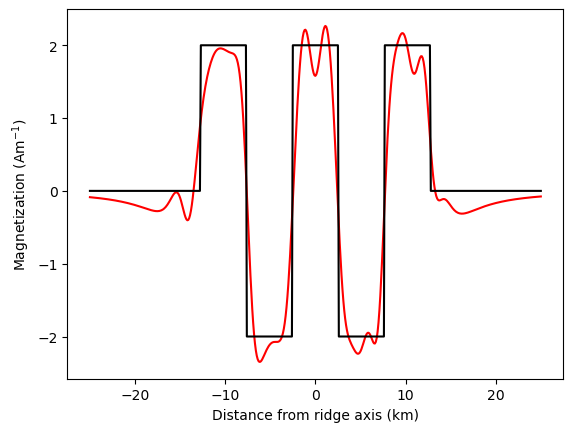

In [10]:
alpha_sq = alpha_sq_list[discrepancy_index]  #For discrepancy principle


# L2 norm Tikhonov Regularized solution
alpha_sq=3.3E1  #For discrepancy principle
#alpha_sq=3.95E1  #For discrepancy principle, old errors
GTG=G.T@G

# Determine Tikhonov solution
I = np.identity(len(GTG))
m_L2tik = np.linalg.solve((GTG + alpha_sq*I), G.T@d_j)

# Residuals
r_L2tik=d_j-G@m_L2tik
# rms misfit
rms_resid_L2tik=np.sqrt(r_L2tik.T@r_L2tik/len(d_j))
print("rms misfit", rms_resid_L2tik[0,0])

## Plot regularized solution: much more reasonable                     
plt.figure()
plt.plot(x_m,m_L2tik,'-r')
plt.plot(x_m, m, 'k')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

Iterations:  430
rms misfit: 8.019011892421762


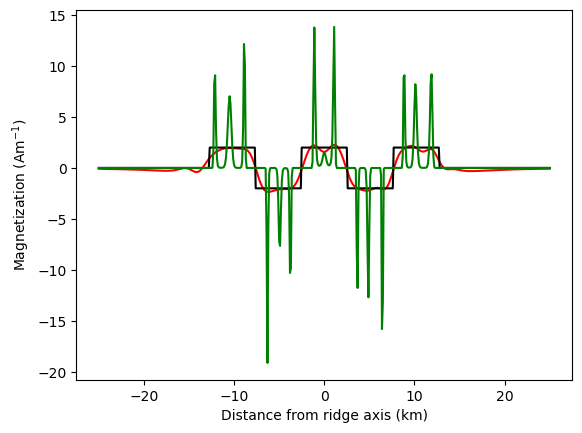

In [11]:
# L1 Regularized solution
delta_sq=1e-8
conv=1
m_L1=np.zeros((len(m_L2tik),1))
w_m=np.ones((len(m_L1),))
alpha_sq_L1=5.8e1
test = []
count = 0
for i in range(500):
    m_L1_old=m_L1
    W_m=np.diag(w_m)
    m_L1 = np.linalg.solve(GTG+alpha_sq_L1*W_m, G.T@d_j)
    w_m=((m_L1**2 + delta_sq)**(-0.5)).reshape(-1,)  # reshape flattens as needed to build diag matrix
    test.append(np.linalg.norm(m_L1_old -m_L1)/np.linalg.norm(m_L1))
    conv=100*np.linalg.norm(m_L1_old -m_L1)/np.linalg.norm(m_L1)
    count += 1
    if conv < 10**(-1):
        break
    
print("Iterations: ", count)
# Residuals
r_L1=d_j-G@m_L1
# rms misfit
rms_resid_L1=np.sqrt(r_L1.T@r_L1/len(d_j))
print("rms misfit:", rms_resid_L1[0,0])                  
                  
plt.figure()
plt.plot(x_m,m_L2tik,'-r')
plt.plot(x_m, m, 'k')
plt.plot(x_m, m_L1, 'g')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

In [17]:
# L1 Regularized 1st diff solution
test = []
conv=1
m_L1d=np.zeros((len(m_L2tik),))
w_md=np.ones((len(m_L1d),))
w_m = np.ones_like(w_md)
# found using discrepancy principle and grid seach, varying one alpha^2 at a time (not easy with >1 alpha^2)
#alpha_sq_L1 = 7. Old version with error in noise
# alpha_sq_L1d = 2e3
alpha_sq_L1 = 5
alpha_sq_L1d = 1.25e3

# Build finite diff H matrix
temp1=np.diag(w_md)
temp2=np.diag(w_md,1)
H=-temp1+temp2[0:501, 0:501]
H[-1,:]=np.zeros((1,501))

count = 0

for i in range(500):
    m_L1_old=m_L1d

    W_md = np.diag(w_md)
    W_m = np.diag(w_m)

    m_L1d = np.linalg.solve(GTG+alpha_sq_L1*W_m+alpha_sq_L1d*H.T@W_md@H, G.T@d_j)
    w_md = (((H@m_L1d)**2 + delta_sq)**(-0.5)).reshape(-1,)
    w_m = ((m_L1d**2 + delta_sq)**(-0.5)).reshape(-1,)  # reshape flattens as needed to build diag matrix


    conv=100*np.linalg.norm(m_L1_old - m_L1d)/np.linalg.norm(m_L1d)
    count += 1
    
    # when the model parameter update becomes small enough, break.
    if conv < 10**(-1):
        break

print("Iterations: ", count)
# Residuals
r_L1d=d_j-G@m_L1d
# rms misfit
rms_resid_L1d=np.sqrt(r_L1d.T@r_L1d/len(d_j))
print("rms misfit:", rms_resid_L1d[0,0])                  

Iterations:  52
rms misfit: 8.000404618347305


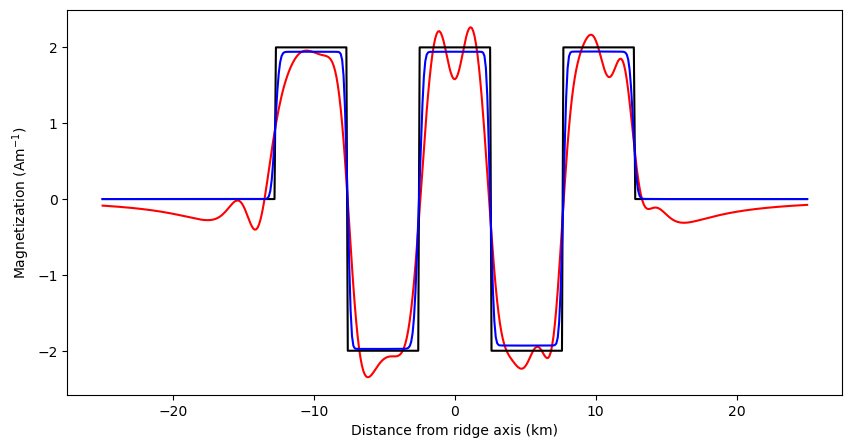

In [18]:
plt.figure(figsize=(10,5))
plt.plot(x_m,m_L2tik,'-r')
plt.plot(x_m, m, 'k')
#plt.plot(x_m, m_L1, 'g')
plt.plot(x_m, m_L1d, 'b')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

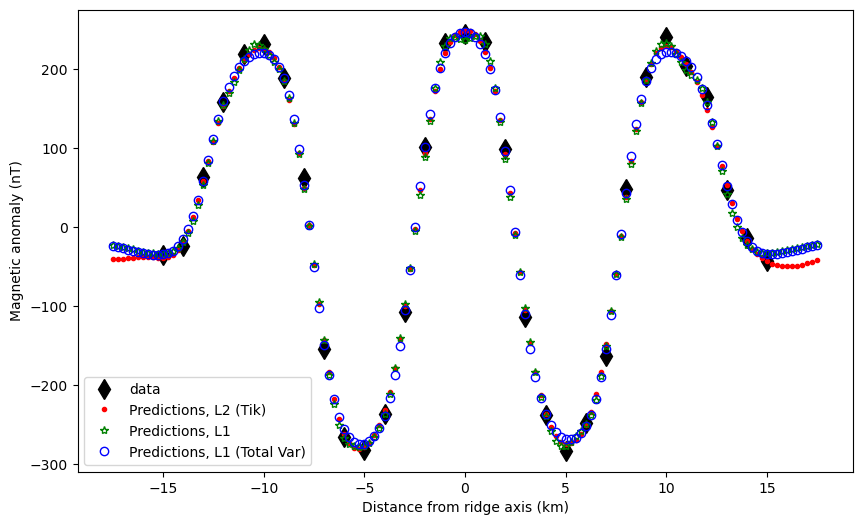

In [19]:
# Figure Comparing data and model predictions

# define locations for model predictions
x_j_pred=np.arange(-17.5,17.5+0.25,0.25)

# Build design matrix
h=2 # Depth of water (km)
Gpred = G_crust(x_j_pred, x_m, h)*delta_x_m


dpred_L1d=Gpred@m_L1d
dpred_L2tik=Gpred@m_L2tik
dpred_L1 = Gpred@m_L1

plt.figure(figsize=(10,6))
plt.plot(x_j,d_j, 'kd', markersize=10, label="data")
plt.plot(x_j_pred,dpred_L2tik, 'r.',label="Predictions, L2 (Tik)")
plt.plot(x_j_pred,dpred_L1, 'g*',fillstyle="none",label="Predictions, L1")
plt.plot(x_j_pred,dpred_L1d, 'bo',fillstyle="none",label="Predictions, L1 (Total Var)")
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel('Magnetic anomaly (nT)')
plt.legend()
plt.show()

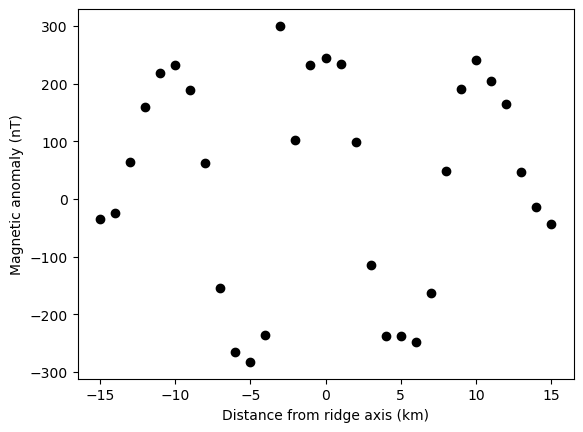

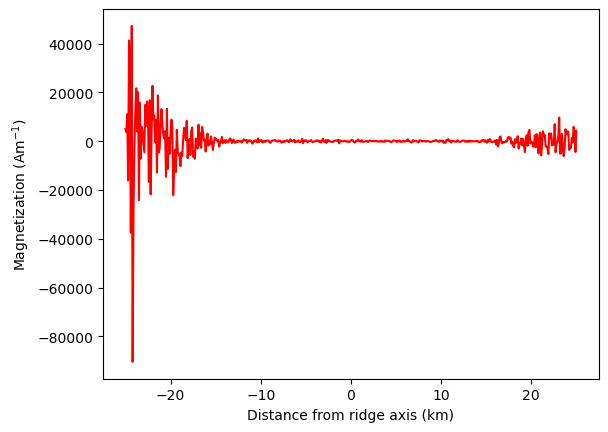

rms misfit: 1.0689013432651455e-11


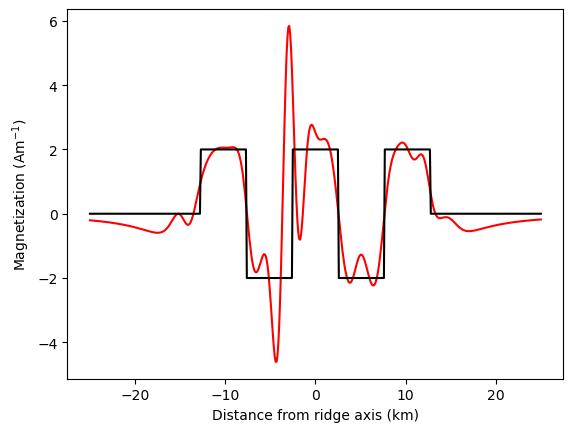

rms misfit: 35.79808326714365


In [20]:
# Solution using Robust Estimation (Huber weights) including outliers

#Add Outliers 
d_j[12]=300
d_j[20]=d_j[19]

# Plot data
plt.figure()
plt.plot(x_j,d_j, 'ko')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel('Magnetic anomaly (nT)')
plt.show()

# Simple least squares soln.
m_ls = np.linalg.solve((G.T@G),G.T@d_j) # Direct least sq inversion: v. poor result

# Plot simple least squares soln
plt.figure()
plt.plot(x_m,m_ls,'-r')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()
# Residuals
r_ls=d_j-G@m_ls;
# rms misfit
rms_resid_ls=np.sqrt(r_ls.T@r_ls/len(d_j))
print("rms misfit:", rms_resid_ls[0,0])

# L2 norm Tikhonov Regularized solution
alpha_sq=3.95E1 

# Determine Tikhonov solution
I = np.identity(len(GTG))
m_L2tik = np.linalg.solve((GTG + alpha_sq*I), G.T@d_j)
## Plot regularized solution: much more reasonable                     
plt.figure()
plt.plot(x_m,m_L2tik,'-r')
plt.plot(x_m, m, 'k')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()
# Residuals
r_L2tik=d_j-G@m_L2tik
# rms misfit
rms_resid_L2tik=np.sqrt(r_L2tik.T@r_L2tik/len(d_j))
print("rms misfit:", rms_resid_L2tik[0,0])

Iterations:  64
rms misfit: 13.91592935500452


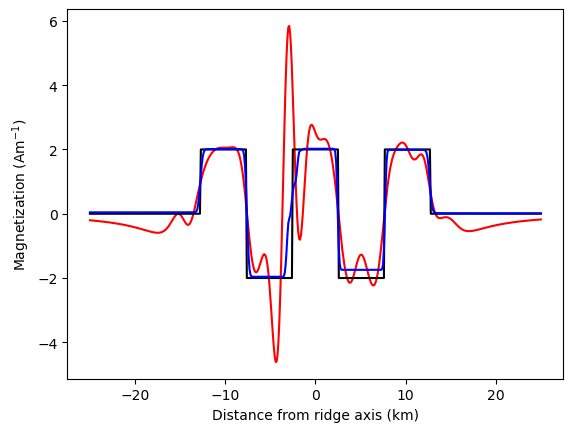

In [21]:
# L1 Regularized 1st diff solution, including Huber weights

conv=1
m_L1d=np.zeros((len(m_L2tik),))
w_md=np.ones((len(m_L1d),))
#alpha_sq_L1=3 Old soln with incorrect errors
#alpha_sq_L1d=3e2
alpha_sq_L1=1 
alpha_sq_L1d=1e3

temp1=np.diag(w_md)
temp2=np.diag(w_md,1)
H=-temp1+temp2[0:501, 0:501]
H[-1,:]=np.zeros((1,501))

w = np.ones((len(d_j),))
w_m=np.ones((len(m_L1d),))
c=1.35
ones_min = np.ones((len(d_j),1))

count = 0
while conv > 10**(-1):
    m_L1_old=m_L1d
    
    W_md=np.diag(w_md)
    W_m=np.diag(w_m)
    W=np.diag(w)
    
    GTWG=G.T@W@G
    
    m_L1d = np.linalg.solve(GTWG+alpha_sq_L1*W_m+alpha_sq_L1d*H.T@W_md@H, G.T@W@d_j)
    w_md=(((H@m_L1d)**2 + delta_sq)**(-0.5)).reshape(-1,)
    w_m =(((m_L1d)**2 + delta_sq)**(-0.5)).reshape(-1,)
    
    res=(d_j-G@m_L1d)/8
    w=np.min([c/abs(res),ones_min],axis=0).reshape(-1,) # Huber
    conv=100*np.linalg.norm(m_L1_old -m_L1d)/np.linalg.norm(m_L1d)
    count += 1
    
print("Iterations: ", count)
# Residuals
r_L1d=d_j-G@m_L1d
# rms misfit
rms_resid_L1d=np.sqrt(r_L1d.T@W@r_L1d/len(d_j))
print("rms misfit:", rms_resid_L1d[0,0])                  
                  
plt.figure()
plt.plot(x_m,m_L2tik,'-r')
plt.plot(x_m, m, 'k')
#plt.plot(x_m, m_L1, 'g')
plt.plot(x_m, m_L1d, 'b')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

In [22]:
# Difficult in this case to match the 8nT misfit level, L-curve would be a better method than discrepancy principle

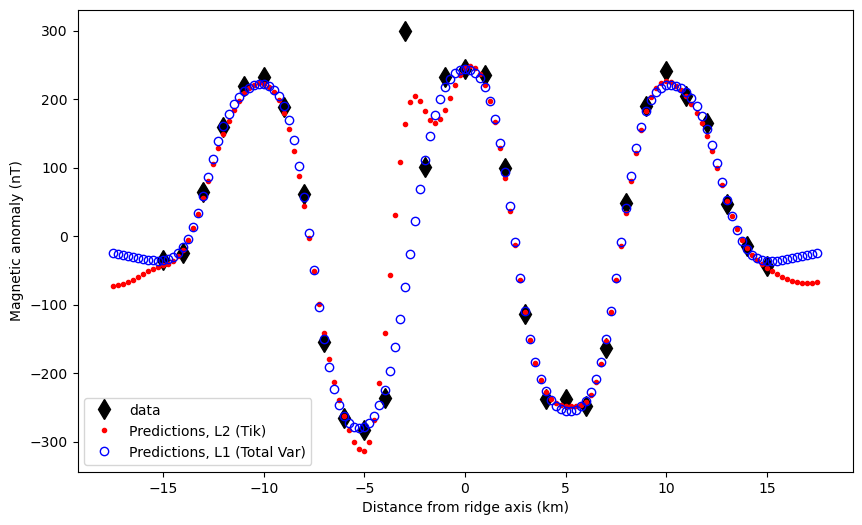

In [23]:
dpred_L1d=Gpred@m_L1d
dpred_L2tik=Gpred@m_L2tik

plt.figure(figsize=(10,6))
plt.plot(x_j,d_j, 'kd', markersize=10, label="data")
plt.plot(x_j_pred,dpred_L2tik, 'r.',label="Predictions, L2 (Tik)")
plt.plot(x_j_pred,dpred_L1d, 'bo',fillstyle="none",label="Predictions, L1 (Total Var)")
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel('Magnetic anomaly (nT)')
plt.legend()
plt.show()